In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib  inline

In [3]:
df=pd.read_csv("random_forest_placement_dataset.csv")
df.head()

,CGPA,Aptitude_Score,Technical_Score,Internship,Placement
0,6.69,76,64,0,0
1,9.28,83,80,1,1
2,8.29,93,63,0,1
3,7.69,76,70,0,0
4,5.70,48,47,1,0


In [4]:
df.isnull().sum()

CGPA               0
Aptitude_Score     0
Technical_Score    0
Internship         0
Placement          0
dtype: int64

In [5]:
df.shape

(100, 5)

In [6]:
#independent and dependent variable
x=df[['CGPA','Aptitude_Score','Technical_Score','Internship']]
y=df['Placement']

In [12]:
#train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [13]:
#model
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(
    n_estimators=100,
    random_state=42
)


In [14]:
model.fit(x_train,y_train)

RandomForestClassifier(random_state=42)

In [15]:
#prediction
y_pred=model.predict(x_test)

In [18]:
print("Predicted value:" , y_pred)
print("Actual Value:" ,y_test)

Predicted value: [1 1 1 1 0 0 1 1 0 0 1 0 1 1 1 0 0 0 1 0]
Actual Value: 83    0
53    1
70    1
45    1
44    0
39    0
22    1
80    1
10    0
0     0
18    0
30    0
73    1
33    1
90    0
4     0
76    0
77    0
12    1
31    0
Name: Placement, dtype: int64


In [21]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
print("Accuracy score:\n",accuracy_score(y_test,y_pred))
print("Confusion matrix:\n",confusion_matrix(y_test,y_pred))
print("classification_report:\n",classification_report(y_test,y_pred))

Accuracy score:
 0.85
Confusion matrix:
 [[9 3]
 [0 8]]
classification_report:
               precision    recall  f1-score   support

           0       1.00      0.75      0.86        12
           1       0.73      1.00      0.84         8

    accuracy                           0.85        20
   macro avg       0.86      0.88      0.85        20
weighted avg       0.89      0.85      0.85        20



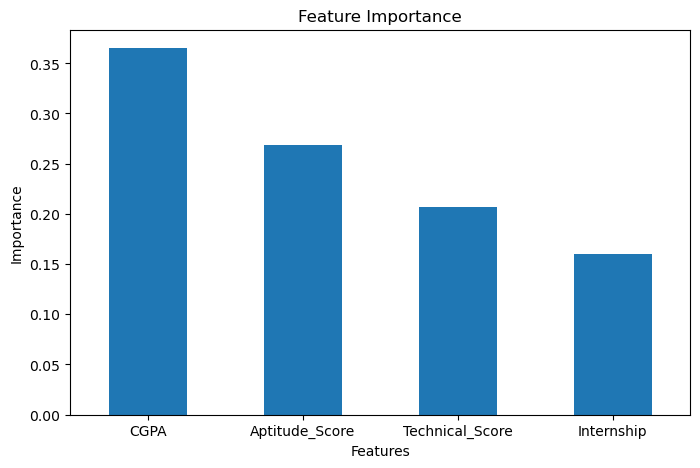

In [35]:
#feature importance
importance=pd.Series(
    model.feature_importances_,
    index=x.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,5))
importance.plot(kind='bar')

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=0)

plt.show()

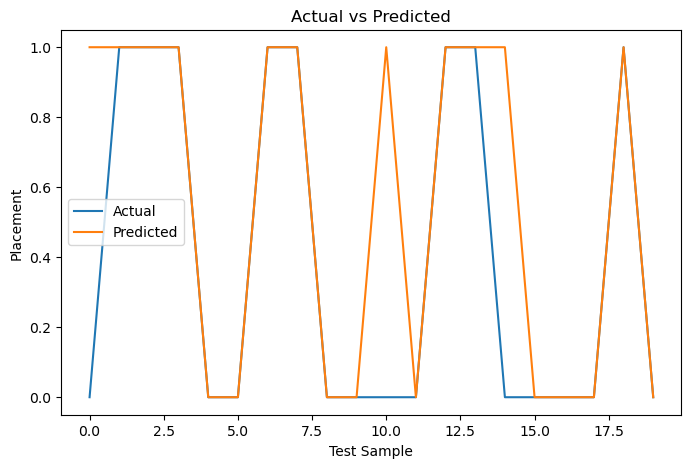

In [25]:
#actual vs Predicted

plt.figure(figsize=(8, 5))

plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")

plt.title("Actual vs Predicted")
plt.xlabel("Test Sample")
plt.ylabel("Placement")
plt.legend()

plt.show()